<a href="https://colab.research.google.com/github/sarath82/cnc-gcode-generator/blob/main/notebooks/train-yolo11-object-detection-on-custom-dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Tue Oct  1 13:03:44 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   47C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [7]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.7/112.6 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [3]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 5, in <module>
    from ultralytics.cfg import entrypoint
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/__init__.py", line 11, in <module>
    from ultralytics.models import NAS, RTDETR, SAM, YOLO, FastSAM, YOLOWorld
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/__init__.py", line 3, in <module>
    from .fastsam import FastSAM
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/fastsam/__init__.py", line 3, in <module>
    from .model import FastSAM
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/fastsam/model.py", line 5, in <module>
    from ultralytics.engine.model import Model
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 8, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 427, in <module>
    from torch._C import *  # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^

**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

In [4]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpeg', width=600)

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/predict/dog.jpeg'

In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="CJrZ9mOWgOwa1GyXDB8W")
project = rf.workspace("sarath-p-hplpx").project("oee-lqvj0")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to OEE-1 in yolov11:: 100%|██████████| 72/72 [00:00<00:00, 7915.23it/s]


### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]

**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [ ]:
result.boxes.xyxy

In [ ]:
result.boxes.conf

In [ ]:
result.boxes.cls

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

In [ ]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("liangdianzhong")
project = workspace.project("-qvdww")
version = project.version(3)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 两点钟模型-3 in yolov11:: 100%|██████████| 2612/2612 [00:00<00:00, 5820.46it/s]


## Custom Training

In [10]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data="/content/OEE-1/data.yaml" epochs=110 imgsz=512 plots=True

/content
New https://pypi.org/project/ultralytics/8.3.237 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/OEE-1/data.yaml, epochs=110, time=None, patience=100, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, sa

In [12]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train4/weights/best.pt")

metrics = model.val(
    data="/content/OEE-1/data.yaml",
    imgsz=512
)

print("Precision:", metrics.box.p)
print("Recall:", metrics.box.r)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)


Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning /content/OEE-1/train/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100%|██████████| 33/33 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 23, len(boxes) = 33. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.70it/s]


                   all         33         33       0.99          1      0.995      0.903
                 GREEN         10         10      0.987          1      0.995      0.895
                   RED         14         14       0.99          1      0.995      0.965
                YELLOW          9          9      0.994          1      0.995      0.849
Speed: 3.0ms preprocess, 13.4ms inference, 0.0ms loss, 6.8ms postprocess per image
Results saved to runs/detect/val
Precision: [    0.98716     0.99043     0.99391]
Recall: [          1           1           1]
mAP50: 0.995
mAP50-95: 0.903137225877193


In [14]:
import pandas as pd

# Load results.csv
df = pd.read_csv("/content/runs/detect/train4/results.csv")

# Take the last epoch row
final = df.iloc[-1]

# Convert metrics to percentage
precision = final["metrics/precision(B)"] * 100
recall = final["metrics/recall(B)"] * 100
map50 = final["metrics/mAP50(B)"] * 100
map5095 = final["metrics/mAP50-95(B)"] * 100

print(f"Precision      : {precision:.2f}%")
print(f"Recall         : {recall:.2f}%")
print(f"mAP@0.5        : {map50:.2f}%")
print(f"mAP@0.5:0.95   : {map5095:.2f}%")



Precision      : 99.11%
Recall         : 100.00%
mAP@0.5        : 99.50%
mAP@0.5:0.95   : 94.54%


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("runs/detect/train3/weights/best.pt")

# Image path (change if needed)
img_path = "/content/test_image.jpg"

# Run inference
results = model(img_path, imgsz=512, conf=0.25)

# Get annotated image
annotated_img = results[0].plot()

# Show image
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis("off")



image 1/1 /content/Gemini_Generated_Image_4wm9n84wm9n84wm9.png: 288x512 (no detections), 9.6ms
Speed: 1.5ms preprocess, 9.6ms inference, 0.5ms postprocess per image at shape (1, 3, 288, 512)


(np.float64(-0.5), np.float64(2815.5), np.float64(1535.5), np.float64(-0.5))

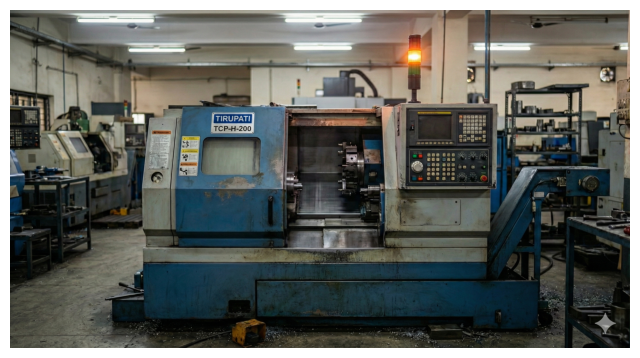

In [18]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("/content/runs/detect/train4/weights/best.pt")

# Image path (change if needed)
img_path = "/content/Gemini_Generated_Image_4wm9n84wm9n84wm9.png"

# Run inference
results = model(img_path, imgsz=512, conf=0.25)

# Get annotated image
annotated_img = results[0].plot()

# Show image
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis("off")


In [19]:
from ultralytics import YOLO
import cv2
from collections import Counter

# Load trained model
model = YOLO("/content/runs/detect/train4/weights/best.pt")

# Video path
video_path = "/content/Untitled design (4).mp4"

# Open video
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = 0

# Frame-wise class counter
frame_counts = Counter()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    total_frames += 1

    # Run YOLO on frame
    results = model(frame, imgsz=512, conf=0.25, verbose=False)

    # If detection exists
    if len(results[0].boxes) > 0:
        # Take the highest confidence detection
        box = results[0].boxes[0]
        cls_id = int(box.cls)
        label = model.names[cls_id]
        frame_counts[label] += 1

cap.release()

# Convert frames to seconds
print("\n===== MACHINE STATE DURATION =====")
for state, frames in frame_counts.items():
    seconds = frames / fps
    print(f"{state.capitalize():<8}: {seconds:.2f} seconds")

print(f"\nTotal video duration: {total_frames / fps:.2f} seconds")



===== MACHINE STATE DURATION =====
Yellow  : 10.07 seconds
Green   : 15.07 seconds
Red     : 15.00 seconds

Total video duration: 40.13 seconds


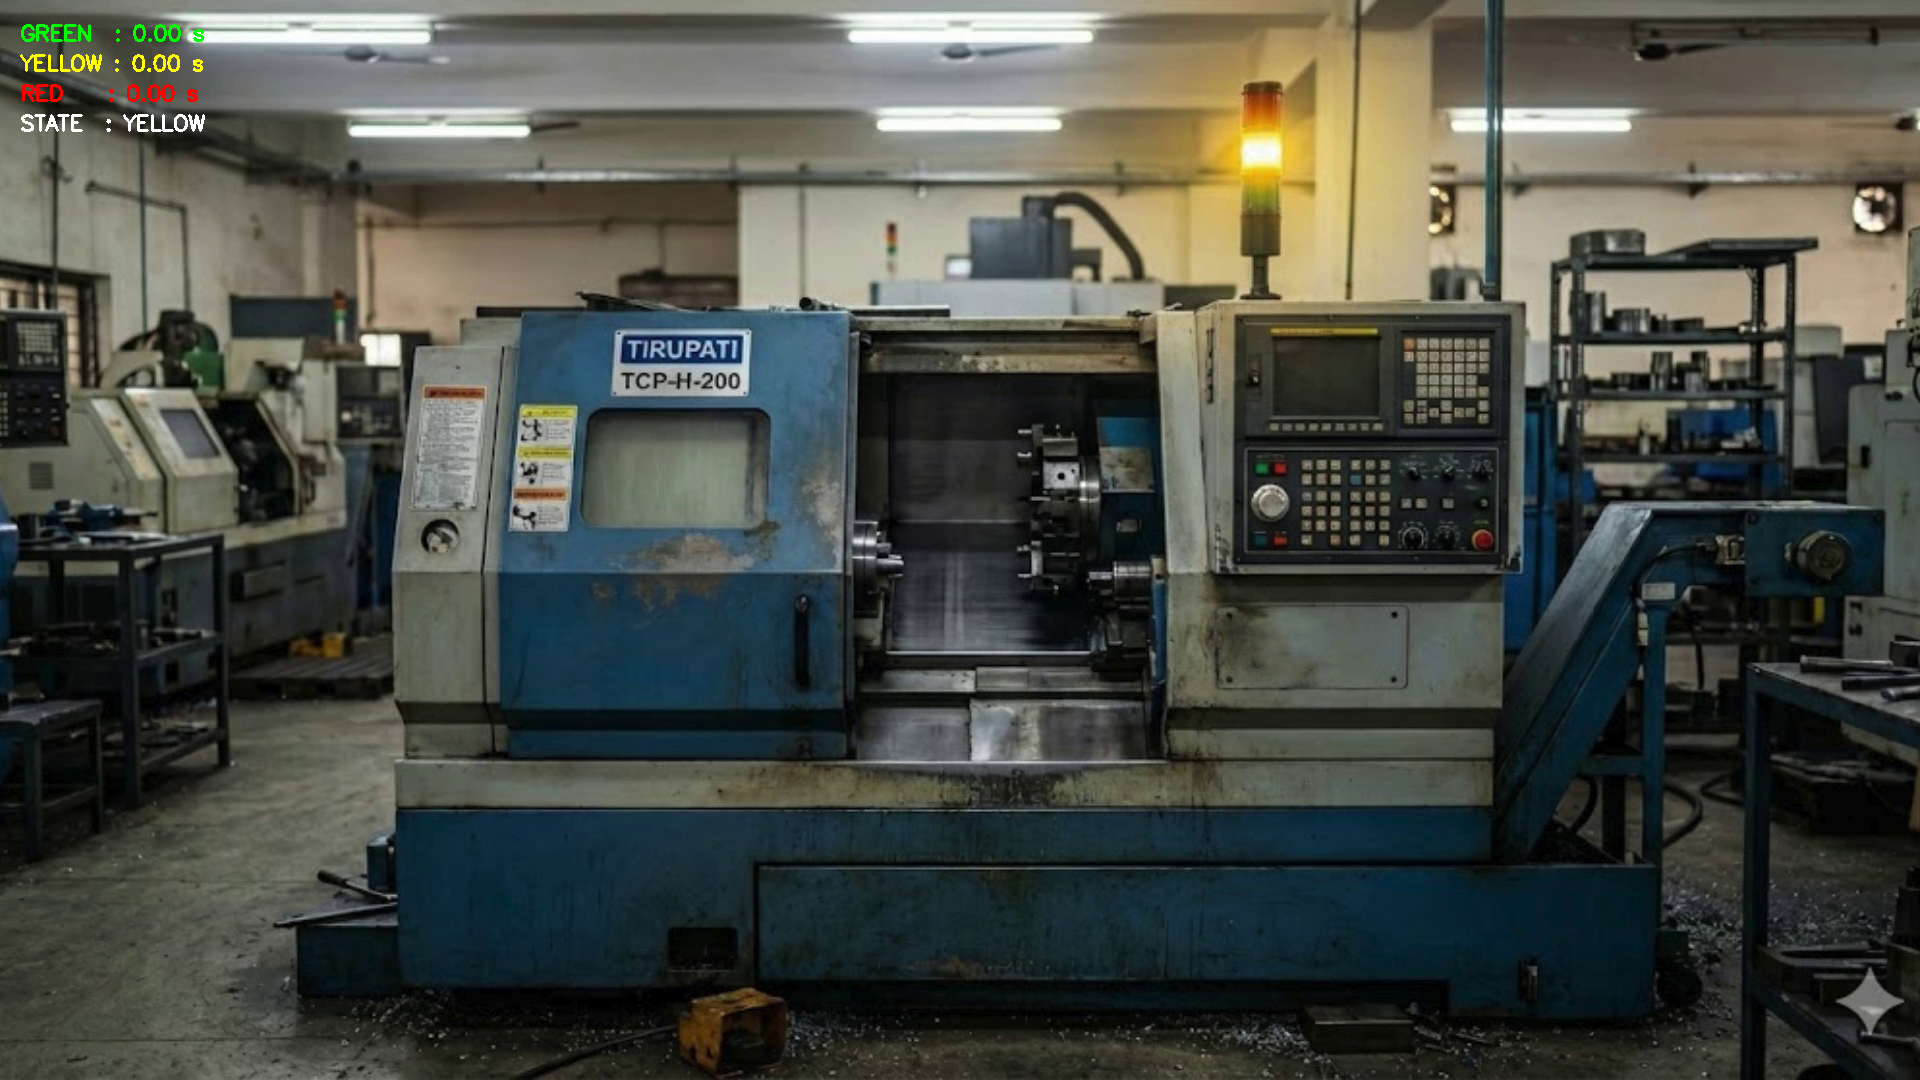

In [ ]:
# ================================
# REAL-TIME CNC STATUS MONITOR
# (Google Colab Compatible)
# ================================

from ultralytics import YOLO
import cv2
import time
from collections import Counter
from google.colab.patches import cv2_imshow
from IPython.display import clear_output

# ----------------
# LOAD MODEL
# ----------------
model = YOLO("/content/runs/detect/train4/weights/best.pt")

# ----------------
# VIDEO SOURCE (acts like live feed)
# ----------------
video_path = "/content/Untitled design (4).mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_delay = 1 / fps

print(f"Video FPS detected: {fps}")

# ----------------
# TIMER VARIABLES
# ----------------
green_time = 0.0
yellow_time = 0.0
red_time = 0.0

current_state = None
last_time = time.time()

# ----------------
# MAIN LOOP
# ----------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Time calculation
    now = time.time()
    elapsed = now - last_time
    last_time = now

    # YOLO inference
    results = model(frame, imgsz=512, conf=0.25, verbose=False)

    if len(results[0].boxes) > 0:
        cls_id = int(results[0].boxes[0].cls)
        current_state = model.names[cls_id]

    # Update only the active state timer
    if current_state == "green":
        green_time += elapsed
    elif current_state == "yellow":
        yellow_time += elapsed
    elif current_state == "red":
        red_time += elapsed

    # ----------------
    # VISUAL OVERLAY
    # ----------------
    cv2.putText(frame, f"GREEN  : {green_time:.2f} s", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
    cv2.putText(frame, f"YELLOW : {yellow_time:.2f} s", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)
    cv2.putText(frame, f"RED    : {red_time:.2f} s", (20, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
    cv2.putText(frame, f"STATE  : {current_state}", (20, 130),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    # ----------------
    # DISPLAY (COLAB SAFE)
    # ----------------
    clear_output(wait=True)
    cv2_imshow(frame)

    # Real-time effect
    time.sleep(frame_delay)

# ----------------
# CLEANUP
# ----------------
cap.release()

# ----------------
# FINAL SUMMARY
# ----------------
print("\n===== FINAL TIME SUMMARY =====")
print(f"GREEN  : {green_time:.2f} seconds")
print(f"YELLOW : {yellow_time:.2f} seconds")
print(f"RED    : {red_time:.2f} seconds")
print(f"TOTAL  : {(green_time + yellow_time + red_time):.2f} seconds")


**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    PR_curve.png	   val_batch0_pred.jpg
confusion_matrix_normalized.png			    R_curve.png		   val_batch1_labels.jpg
confusion_matrix.png				    results.csv		   val_batch1_pred.jpg
events.out.tfevents.1727788453.c5dcf32815d2.3299.0  results.png		   val_batch2_labels.jpg
F1_curve.png					    train_batch0.jpg	   val_batch2_pred.jpg
labels_correlogram.jpg				    train_batch1.jpg	   weights
labels.jpg					    train_batch2.jpg
P_curve.png					    val_batch0_labels.jpg


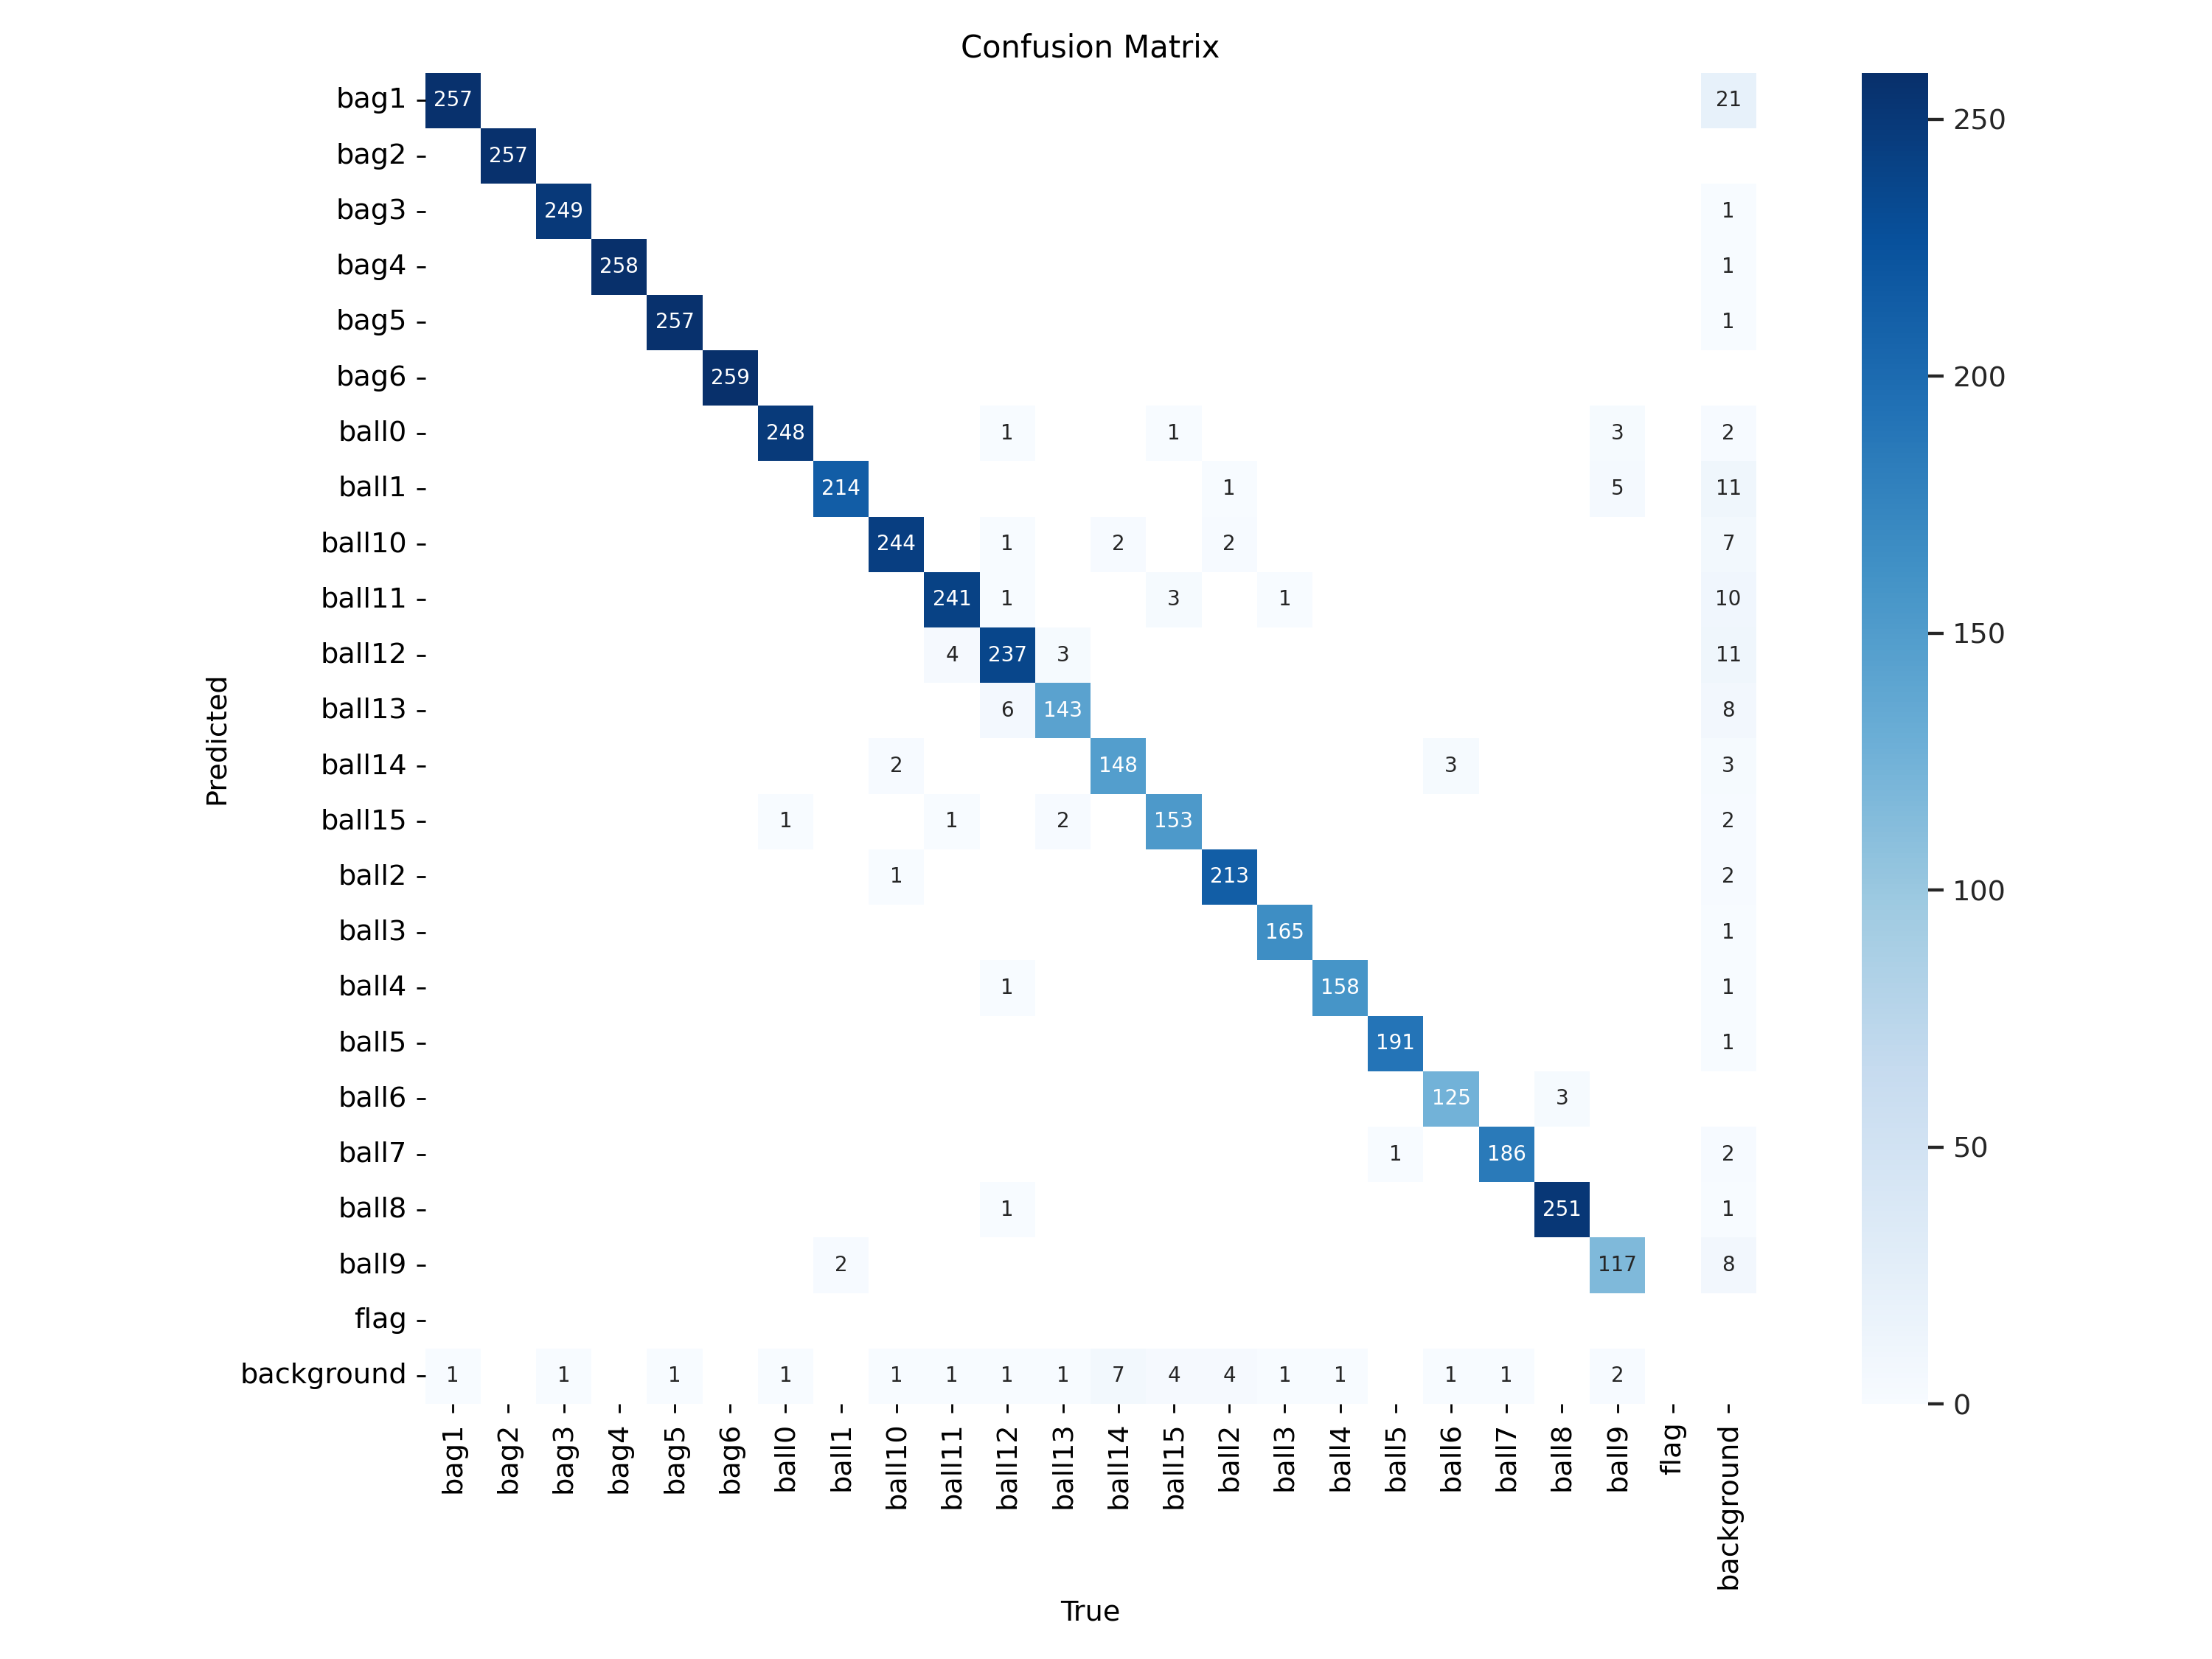

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

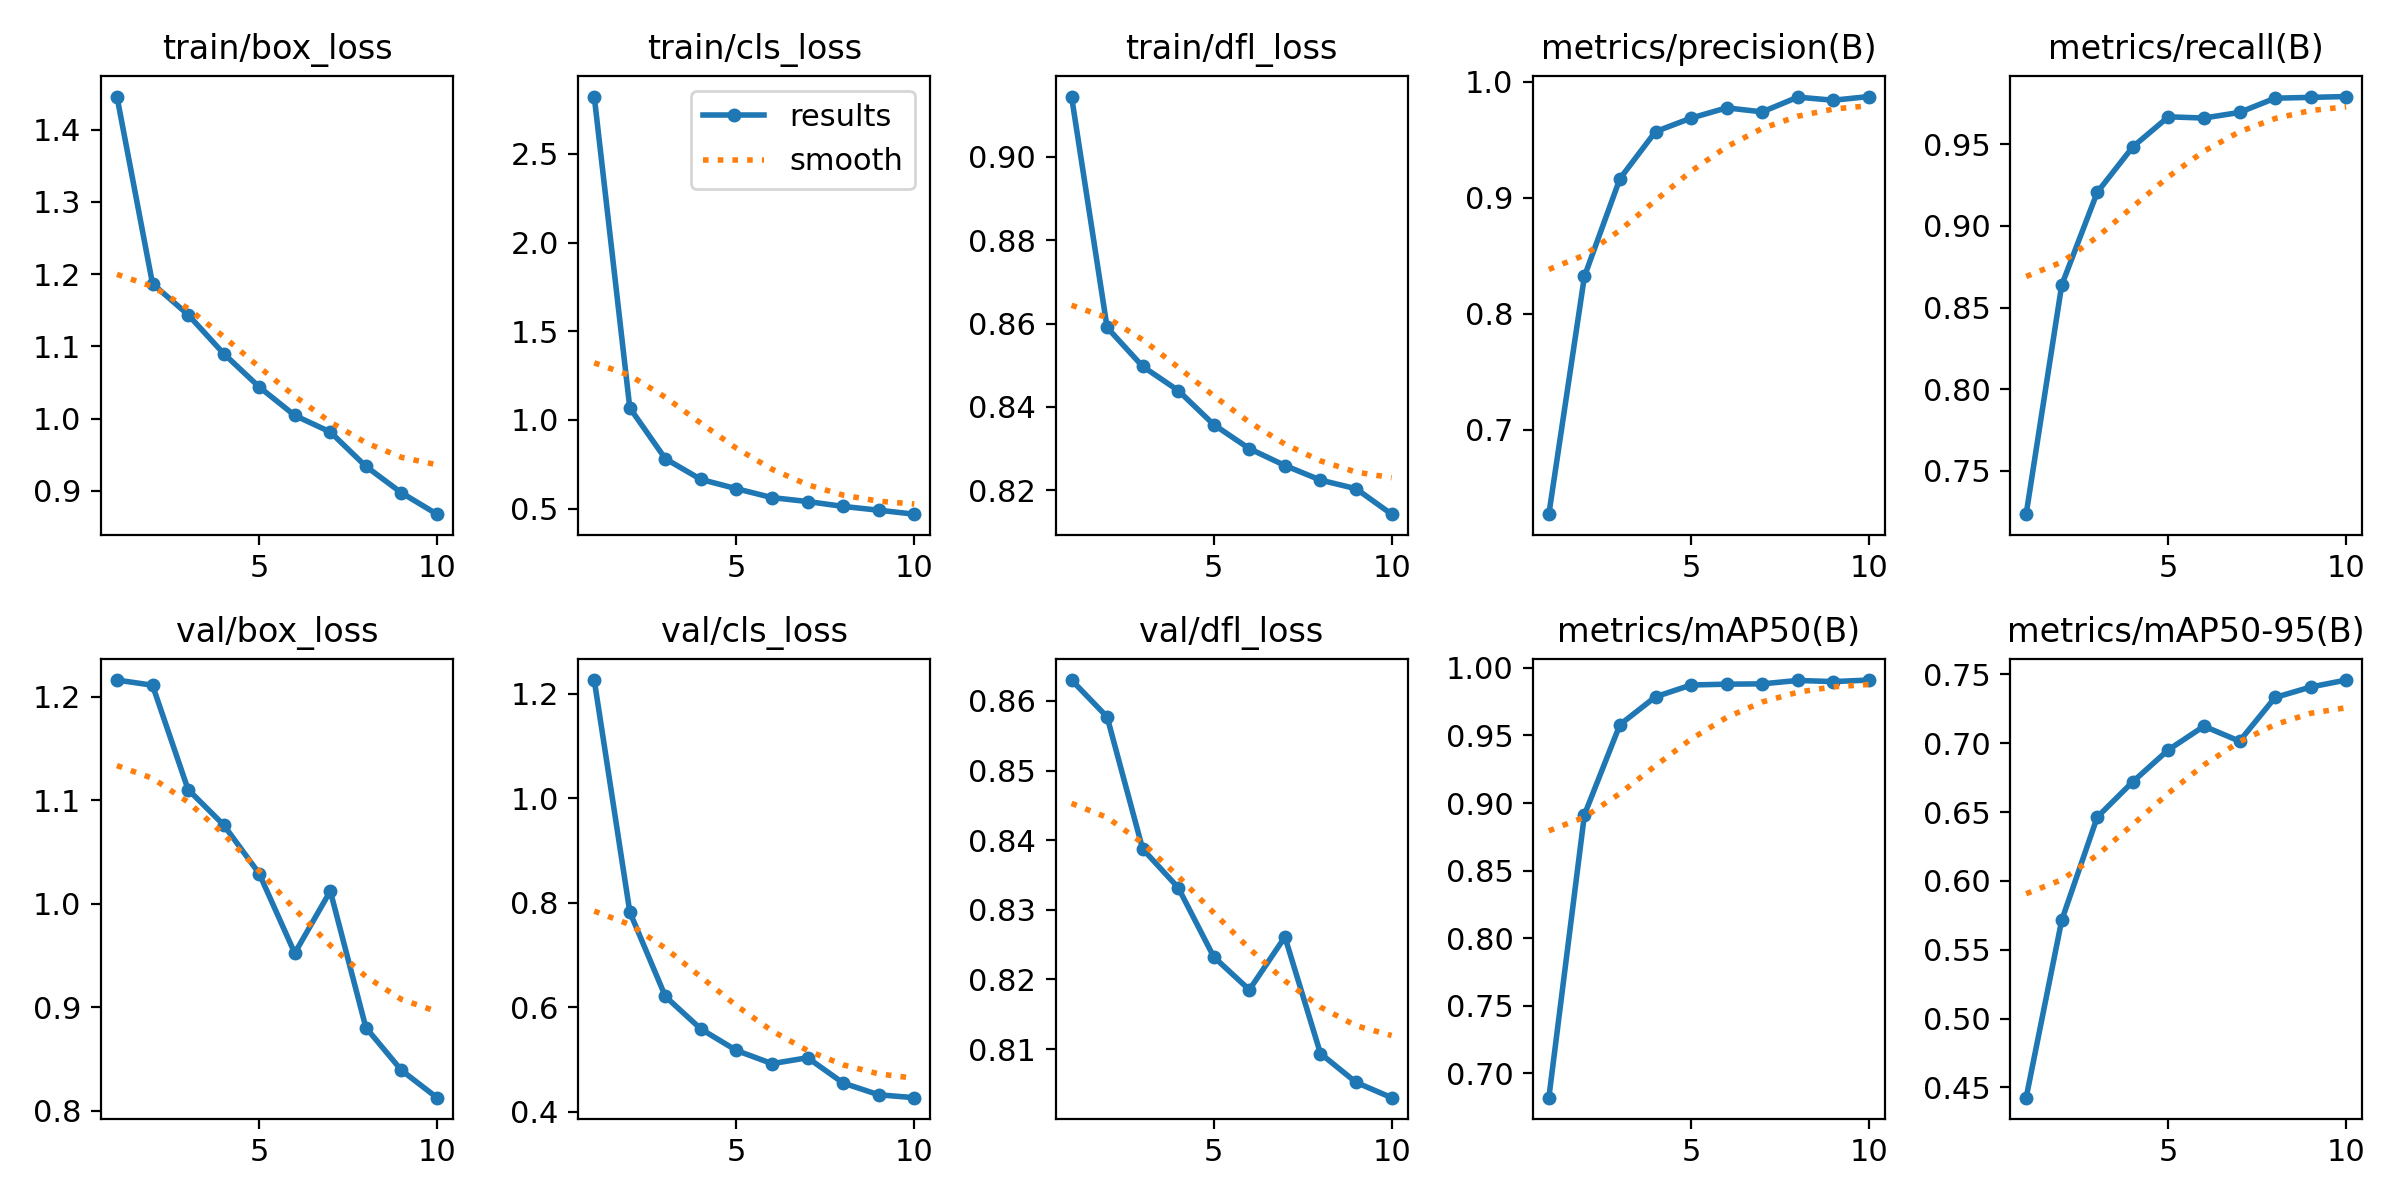

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

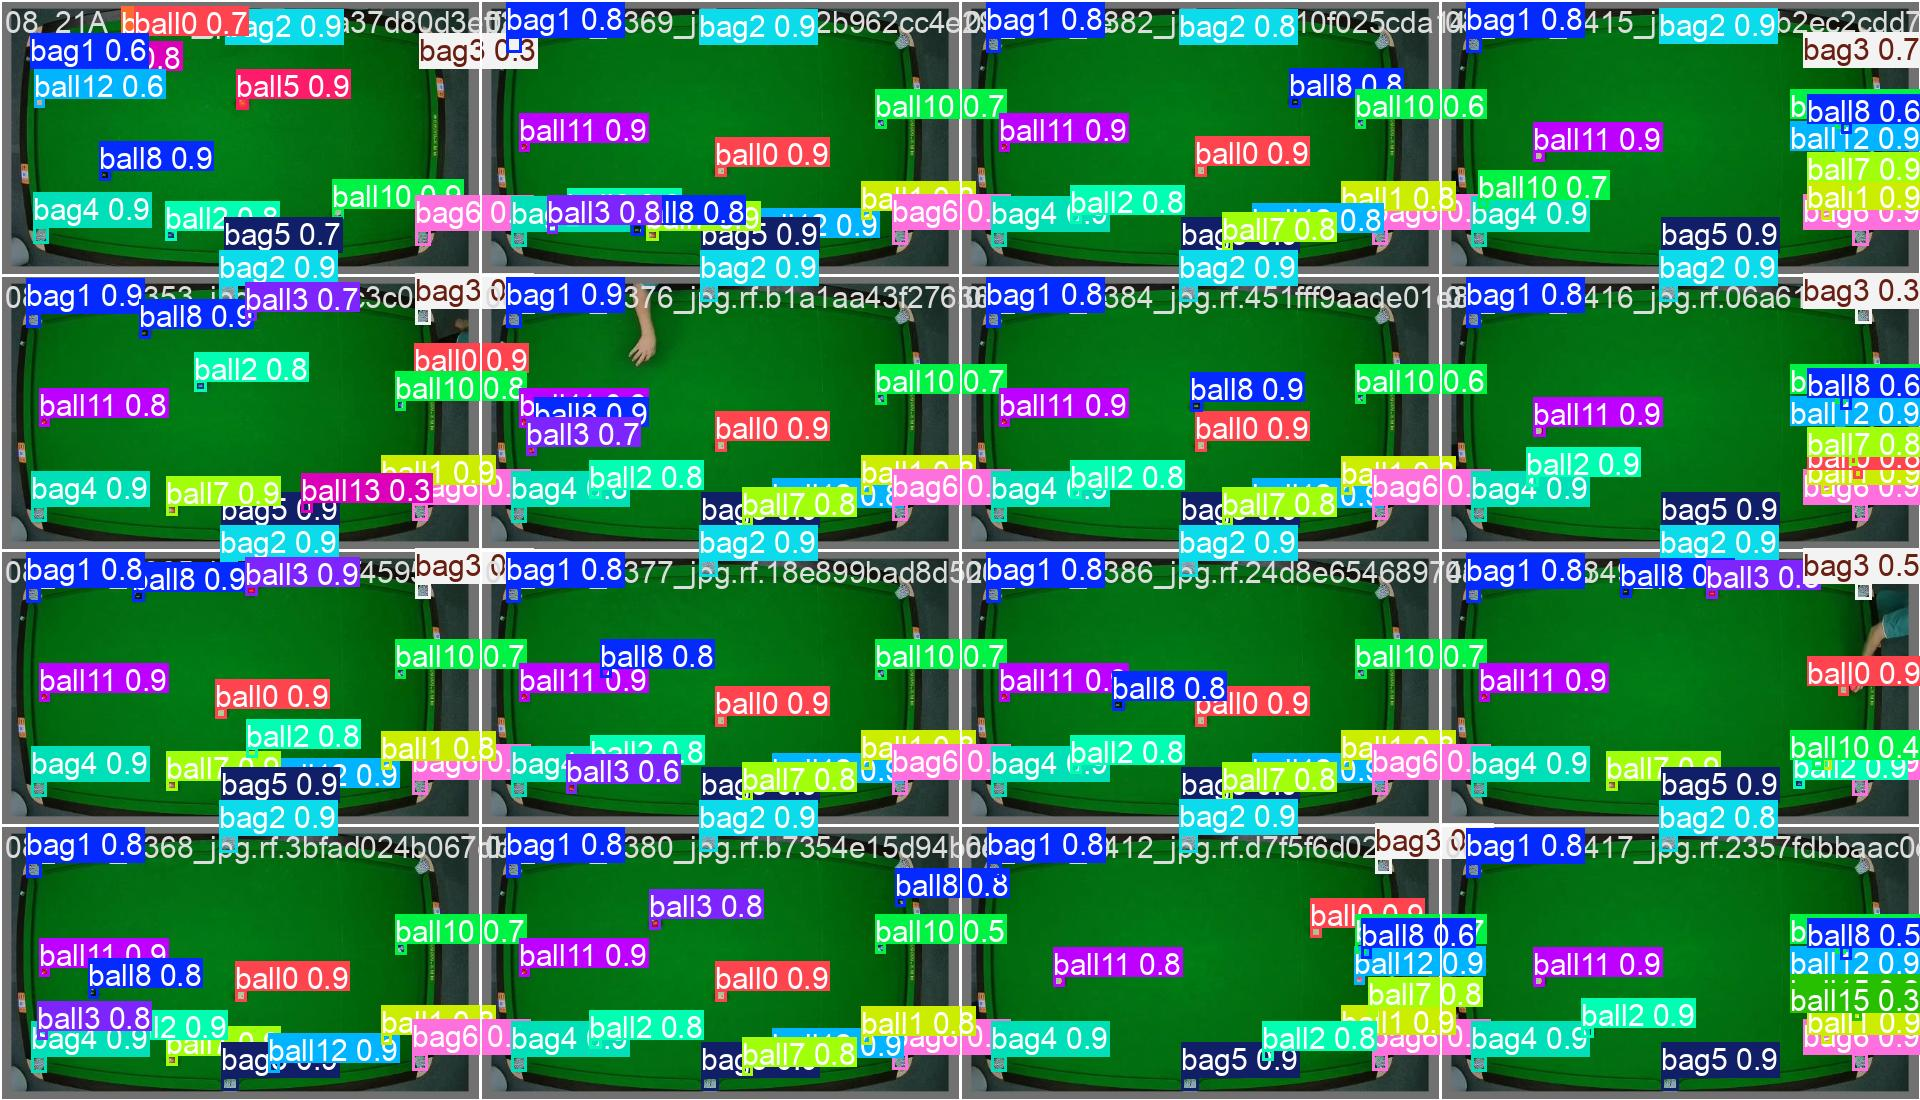

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.2 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s summary (fused): 238 layers, 9,421,701 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/两点钟模型-3/valid/labels.cache... 259 images, 0 backgrounds, 0 corrupt: 100% 259/259 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/datasets/两点钟模型-3/valid/images/08_21C_0250_jpg.rf.b164fca68a7a644a126019aa776912c1.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 17/17 [00:06<00:00,  2.59it/s]
                   all        259       4652      0.987      0.979      0.991      0.749
                  bag1        258        258      0.986      0.984      0.994       0.78
                  bag2        257        257      0.998          1      0.995      0.892
                  bag3        250        250          1      0.942      0.995      0.808
                  bag4        258        258      0.996          1      0.995      0

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

**NOTE:** Let's take a look at few results.

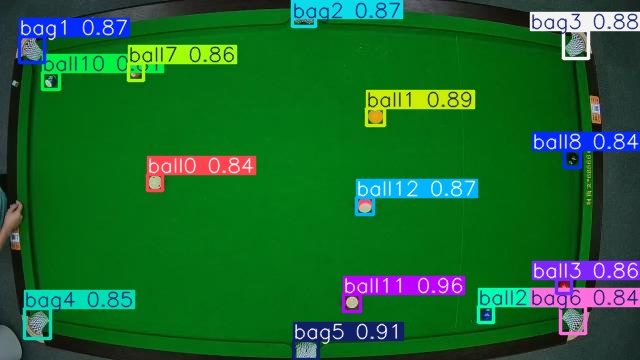

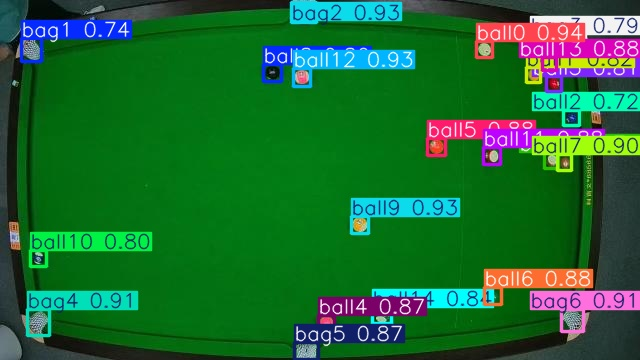

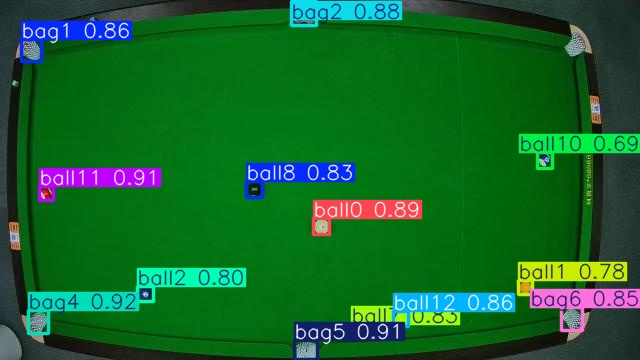

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [ ]:
project.version(dataset.version).deploy(model_type="yolov11", model_path=f"{HOME}/runs/detect/train/")

In [ ]:
!pip install inference

In [ ]:
import os, random, cv2
import supervision as sv
import IPython
import inference

model_id = project.id.split("/")[1] + "/" + dataset.version
model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

# Location of test set images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference
    results = model.infer(image, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.